In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
class Weak_Supervision_Dataset():    
    def __init__(self, img_dir,lbl_dir, lat, lon, transforms=None):
        
        self.transforms = transforms
        markers = set()
        self.planet_paths = []
        self.sentinel_paths = {}
        self.cicyano_paths ={}
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.lat = lat,
        self.lon = lon

        for file in sorted(listdir(self.img_dir)):
            parts = file.split('_')[0]  
            if parts not in markers:
                self.planet_paths.append(os.path.join(self.img_dir, file))
                markers.add(parts)

        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'CIcyano':
                            if marker not in self.cicyano_paths: 
                                self.cicyano_paths[marker] = os.path.join(folder_path, file)
                                
        for folder in sorted(os.listdir(self.lbl_dir)):
            if folder not in [".DS_Store", ".ipynb_checkpoints"]:
                folder_path = os.path.join(self.lbl_dir, folder)
                for file in sorted(os.listdir(folder_path)):
                    if file.endswith('.tif'):
                        parts = file.split('.')
                        name = parts[-3] 
                        marker = parts[1][:4] + parts[2]  
                        if marker in markers and name == 'truecolor':
                            if marker not in self.sentinel_paths: 
                                self.sentinel_paths[marker] = os.path.join(folder_path, file)
                                

        self.matches = {}
        for img_path in self.planet_paths:
            img_marker = img_path.split('/')[-1].split('_')[0]  
            if img_marker in markers:
                self.matches[img_marker] = {
                    'planet': img_path,
                    'cicyano': self.cicyano_paths.get(img_marker, None),
                    'sentinel': self.sentinel_paths.get(img_marker,None)
                }
        
        self.matches = {marker: paths for marker, paths in self.matches.items() if paths['cicyano'] is not None}
        self.keys = list(self.matches.keys())

    def __len__(self): return len(self.matches)
    
    def __getitem__(self, idx):
        marker = self.keys[idx]
        
        #planet image handling 
        with rio.open(self.matches[marker]['planet']) as rds:
            data = rds.read([1,2,3])
            planet_data = np.array(data) #shape (3,600,600)
#             planet_data = np.moveaxis(planet_data, 0,2) #to match axis order of NASA data
            
        with rio.open(self.matches[marker]['sentinel']) as rds:
            data = rds.read([1,2,3])
            unalt = data
            crop_size = 2.5

            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)
     
            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            sentinel_data = np.array(data)

        #label handling
        with rio.open(self.matches[marker]['cicyano']) as rds:
            data = rds.read()
            crop_size = 2.5
            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(self.lon, self.lat)
            row, col = rds.index(xx, yy)

            row_start = max(row - crop_size, 0)
            row_end = min(row + crop_size, rds.height)
            col_start = max(col - crop_size, 0)
            col_end = min(col + crop_size, rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read(window=window)
            lbl_arr = np.array(data)

            fpt_avg = np.where((31 <= lbl_arr) & (lbl_arr<= 249), lbl_arr, 0) #bloom pixel avg only
            fpt_avg = fpt_avg[fpt_avg !=0]
            mean_value = fpt_avg.mean() if fpt_avg.size > 0 else 0

            #label with land (2), cloud (3), bloom (1), else (0)
            fptdata = np.where(lbl_arr == 252, 2, np.where(lbl_arr == 253, 3, np.where((31 <= lbl_arr) & (lbl_arr<= 249), 1, 0)))
#             num_classes = 4
#             one_hot_labels = np.eye(num_classes)[fptdata]  # Shape: (H, W, 4)
#             fptdata_dim = np.moveaxis(one_hot_labels, -1, 0)  # Shape: (4, H, W)
            
            if 31 <= mean_value <= 249:
                class_lbl = 1
            else: class_lbl = 0
                

        sample ={'planet': planet_data,
                  'planet_file': self.matches[marker]['planet'],
                  'sentinel': sentinel_data,
                  'sentinel_file': self.matches[marker]['sentinel'],
                  'cicyano': fptdata,
                  'cicyano_file': self.matches[marker]['cicyano'],
                  'ci_avg': round(mean_value),
                  'class_label': class_lbl
                 }

        if self.transforms:
            sample = self.transforms(sample)

        return sample
        
    def display(self, idx):

        sample = self[idx]
        planet = sample['planet']
        sentinel = sample['sentinel']
        cicyano = sample['cicyano']
        label = sample['ci_avg']

        class_label = sample['class_label']
        inf = sample['planet_file'].split('/')

        d=inf[-1].split('_')[0]
        d = d[4:6]+'-'+d[6:]+'-'+d[:4]
        p = inf[-2]
        
        colors = ['black', 'seagreen', 'yellow', 'grey']  # Set your desired colors for each class here
        cmap = ListedColormap(colors)
        boundaries = [0, 1, 2, 3, 4]  # Each boundary represents a class (0, 1, 2, 3)
        norm = BoundaryNorm(boundaries, cmap.N)
        fig,(ax1, ax2,ax3) = plt.subplots(1,3, figsize=(9,9))
        fig.suptitle(f' {d} at {p}',y=0.68)
        
        ax1.imshow(torch.permute(planet, (1,2,0)), zorder=1)
        ax1.axis('off')
        ax1.set_title(f'Planet')
        grid_color = 'white'
        linewidth = 0.1
        for i in range(1, 5):
            # Draw vertical lines
            ax1.vlines(x=planet.shape[1] * i / 5, ymin=0, ymax=planet.shape[0], color=grid_color, linewidth=linewidth)
            # Draw horizontal lines
            ax1.hlines(y=planet.shape[0] * i / 5, xmin=0, xmax=planet.shape[1], color=grid_color, linewidth=linewidth)

 
        ax2.imshow(torch.permute(cicyano, (1,2,0)), cmap=cmap,norm=norm)
        ax2.axis('off')
        ax2.set_title(f'Class Label: {class_label}')

        ax3.imshow(torch.permute(sentinel, (1,2,0)))
        ax3.axis('off')
        ax3.set_title(f'Sentinel Avg Label: {round(label)}')
        plt.show()

        return fig


def create_dataset(*args, apply_transforms=True, **kwargs):
    if apply_transforms:
        data_transforms = transforms.Compose([
            FlipsAndTricks(),
            CropAndChop(512),
#             Normalize(),
            ToTensor(),])
    else: data_transforms = None

    data = Weak_Supervision_Dataset(*args, **kwargs, transforms=data_transforms)
    return data

In [3]:
lbl_dir = '/datacommons/carlsonlab/srs108/blooms/all_data'

img_dir = '/datacommons/carlsonlab/srs108/crops/arrowhead_beach/'
lat,lon = 36.236724, -76.698134
a=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/cannons_ferry/'
lat,lon = 36.272006, -76.675842
b=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/chowan_river/'
lat,lon = 36.055163, -76.690760
c=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/mt_gould/'
lat,lon = 36.125495, -76.740141
d=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/point_comfort/'
lat,lon = 36.169908, -76.745905
e=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)

img_dir = '/datacommons/carlsonlab/srs108/crops/rocky_hock_lane/'
lat,lon = 36.184133, -76.722858
f=create_dataset(img_dir, lbl_dir, lat, lon, apply_transforms=True)
all_chowan = torch.utils.data.ConcatDataset([a,b,c,d,e,f])

val_ratio, test_ratio = 0.25, 0.25
dataset_size = len(all_chowan)
indices = list(range(dataset_size))
batch_size = 8

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(all_chowan, train_indices)
val_dataset = Subset(all_chowan, val_indices)
test_dataset = Subset(all_chowan, test_indices)

In [4]:
# all_labels = [train_dataset[i]['class_label'] for i in tqdm(range(len(train_dataset)))]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [5]:
# torch.save((class_counts, class_weights, sample_weights), 'unet_weights.pth')
class_counts, class_weights, sample_weights = torch.load('unet_weights.pth')

In [6]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [7]:
def train(model, pool, dataloader, criterion, opt, device):
    running_loss = 0
    model.train()
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    iou_scores = torch.zeros(4, device=device)
    total_intersection = 0
    total_union = 0
    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['planet'].float().to(device)
        y = batch['cicyano'].squeeze(dim=1).to(device)
        output = model(x)
        reduced_output = pool(output)

        #loss
        loss = criterion(reduced_output,y)
        running_loss += loss.item()

        #predictions
        softmax = nn.Softmax(dim=1)
        preds = torch.argmax(softmax(reduced_output),axis=1)
        
        #accuracy
        num_correct += (preds == y).sum()
        num_pixels += torch.numel(preds)
        
        #dice
        dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)    

        #iou
        for cls in range(4):  # Assuming 4 classes (0, 1, 2, 3)
            intersection = ((preds == cls) & (y == cls)).sum()
            union = ((preds == cls) | (y == cls)).sum()
            total_intersection += intersection
            total_union += union
            if union > 0:
                iou_scores[cls] += intersection / union


        opt.zero_grad()
        loss.backward()
        opt.step()
        torch.cuda.empty_cache()
#         if i == 5:
#             break
    avg_iou = (iou_scores / len(dataloader)).cpu().numpy()
    overall_iou = (total_intersection / (total_union + 1e-8)).item()
    
    dice = (dice_score / len(dataloader)).item()
    acc = (num_correct / num_pixels).item()
    loss = running_loss/len(dataloader)
    
    return  loss, dice, acc, avg_iou, overall_iou

In [8]:
def test(model, pool, dataloader, criterion, device):
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    running_loss = 0
    model.eval()
    iou_scores = torch.zeros(4, device=device)
    total_intersection = 0
    total_union = 0
    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['planet'].float().to(device)
            y = batch['cicyano'].squeeze(dim=1).to(device)
            output = model(x)
            reduced_output = pool(output)
            #loss 
            loss = criterion(reduced_output,y)
            running_loss += loss.item()
            #predictions
            softmax = nn.Softmax(dim=1)
            preds = torch.argmax(softmax(reduced_output),axis=1)

            #accuracy
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)

            #dice
            dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)    

            #iou
            for cls in range(4):  # Assuming 4 classes (0, 1, 2, 3)
                intersection = ((preds == cls) & (y == cls)).sum()
                union = ((preds == cls) | (y == cls)).sum()
                total_intersection += intersection
                total_union += union
                if union > 0:
                    iou_scores[cls] += intersection / union
            
            torch.cuda.empty_cache()
            
#             if i ==5:
#                 break
        avg_iou = (iou_scores / len(dataloader)).cpu().numpy()
        overall_iou = (total_intersection / (total_union + 1e-8)).item()
        
        dice = (dice_score/len(dataloader)).item()
        acc = ( num_correct/num_pixels).item()
        loss = running_loss/len(dataloader)
    return loss,dice, acc, avg_iou, overall_iou


In [9]:
def main(model, epochs):
    opt                     = optim.Adam(model.parameters(), lr=1e-5)#, momentum = 0.9)
    criterion               = nn.CrossEntropyLoss().to(device)  
    pool                    = nn.AdaptiveAvgPool2d((5, 5))

    best_loss               = 1e6
    patience                = np.ceil(0.1*epochs)
    trigger_times           = 0
    history = {'epoch':[],'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc':[], 'train_dice': [], 'val_dice':[], 'train_iou_bloom':[], 'val_iou_bloom':[], 'all_train_iou':[], 'all_val_iou':[]}

    for epoch in range(1, epochs+1):
        train_loss, train_dice, train_acc, train_iou, overall_train_iou = train(model, pool, train_loader, criterion, opt, device)
        val_loss, val_dice, val_acc, val_iou, overall_val_iou = test(model, pool, val_loader, criterion, device)
        
        if val_loss < best_loss:
            trigger_times = 0
            best_loss = val_loss
            best_model_weights = model.state_dict()
            torch.save(model.state_dict(), 'weak_weights.pt')

        else:
            trigger_times += 1
            if trigger_times == patience:
                print(f"Early stopping on epoch {epoch} - patience reached")
                break
        
        print(f'Epoch {epoch} Current Train/Val:\n\tLoss: {round(train_loss, 5)}/{round(val_loss, 5)}\n\tAccuracy: {round(train_acc,5)}/{round(val_acc,5)}\n\tIoU: {round(train_iou[2],5)}/{round(val_iou[2],5)}')
        
        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['train_iou_bloom'].append(train_iou[2])
        history['val_iou_bloom'].append(val_iou[2])
        history['all_train_iou'].append(overall_train_iou)
        history['all_val_iou'].append(overall_val_iou)
        
        
        
        df = pd.DataFrame(history)
        df.to_csv('csv_weak.csv', index=False)
        torch.cuda.empty_cache()

In [11]:
# model = unet_model().to(device)
model  = smp.Unet(encoder_name = 'resnet18', encoder_weights = 'imagenet', in_channels = 3,classes = 4).to(device)

main(epochs = 250, model=model)

In [10]:
df = pd.read_csv('/datacommons/carlsonlab/srs108/weak/unet/csv_weak.csv')
trainloss = min(df['train_loss'])
valloss = min(df['val_loss'])
trainacc = max(df['train_acc'])
valacc = max(df['val_acc'])
traindice = max(df['train_dice'])
valdice = max(df['val_dice'])
trainiou = max(df['train_iou_bloom'])
valiou = max(df['val_iou_bloom'])

In [11]:
print(f'Training Accuracy: {trainacc}\nValidation Accuracy: {valacc}\nTraining Loss: {trainloss}\nValidation Loss: {valloss}')
print(f'Training Dice :{traindice}\nValidation Dice: {valdice}\nTraining IoU: {trainiou}\nValidation IoU: {valiou}')

Training Accuracy: 0.936862289905548
Validation Accuracy: 0.927687168121338
Training Loss: 0.2461597339099834
Validation Loss: 0.2932504250039888
Training Dice :1.727656364440918
Validation Dice: 1.6736371517181396
Training IoU: 0.9165018
Validation IoU: 0.84230065


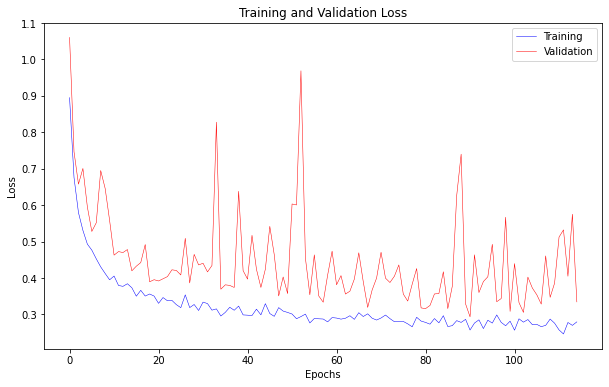

In [12]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=False, fig_name = '/hpc/home/srs108/unet_loss')

In [ ]:
train_val_acc(df['train_dice'], df['val_dice'], len(df['epoch']), save=True, fig_name = '/hpc/home/srs108/unet_acc')

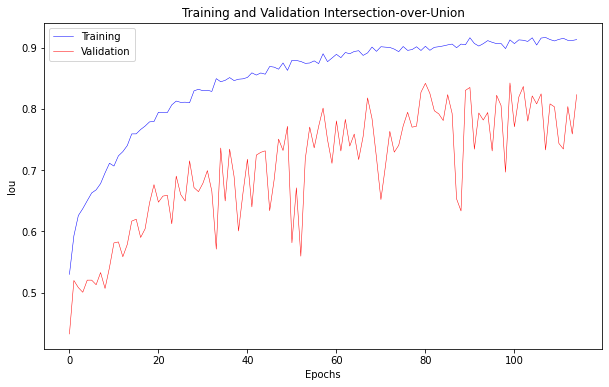

In [13]:
train_val_iou(df['train_iou_bloom'], df['val_iou_bloom'], len(df['epoch']), save=False, fig_name = '/hpc/home/srs108/unet_iou')

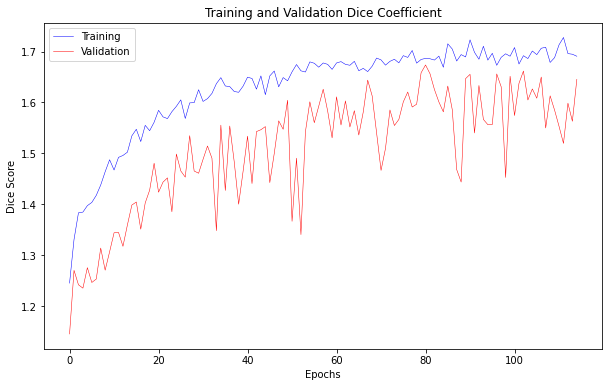

In [14]:
train_val_dice(df['train_dice'],df['val_dice'], len(df['epoch']), save = False, fig_name = '/hpc/home/srs108/unet_dice')

# Testing

In [9]:
model = unet_model().to(device)
model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/unet/weights_weak.pt'))

<All keys matched successfully>

In [10]:
criterion               = nn.CrossEntropyLoss().to(device)  
pool                    = nn.AdaptiveAvgPool2d((5, 5))

num_correct = 0
num_pixels = 0
dice_score = 0
running_loss = 0
model.eval()
iou_scores = torch.zeros(4, device=device)
total_intersection = 0
total_union = 0
with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['planet'].float().to(device)
        y = batch['cicyano'].squeeze(dim=1).to(device)
        output = model(x)
        reduced_output = pool(output)
        #loss 
        loss = criterion(reduced_output,y)
        running_loss += loss.item()
        #predictions
        softmax = nn.Softmax(dim=1)
        preds = torch.argmax(softmax(reduced_output),axis=1)

        #accuracy
        num_correct += (preds == y).sum()
        num_pixels += torch.numel(preds)

        #dice
        dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)    

        #iou
        for cls in range(4):  # Assuming 4 classes (0, 1, 2, 3)
            intersection = ((preds == cls) & (y == cls)).sum()
            union = ((preds == cls) | (y == cls)).sum()
            total_intersection += intersection
            total_union += union
            if union > 0:
                iou_scores[cls] += intersection / union

        torch.cuda.empty_cache()

#         if i ==5:
#             break
overall_iou = (total_intersection / (total_union + 1e-8)).item()
avg_iou = (iou_scores / len(test_loader)).cpu().numpy()
dice = (dice_score/len(test_loader)).item()
acc = ( num_correct/num_pixels).item()
loss = running_loss/len(test_loader)


150it [02:31,  1.01s/it]


In [18]:
print(f"Loss: {loss:.4f}, Dice: {dice:.4f}, Accuracy: {acc:.4f}\nBloom IoU: {avg_iou[2]}Total IoU {overall_iou}")


Loss: 0.5841, Dice: 0.4501, Accuracy: 0.8086
Bloom IoU: 0.15928830206394196Total IoU 0.6786503791809082


In [11]:
print(f"Loss: {loss:.4f}, Dice: {dice:.4f}, Accuracy: {acc:.4f}\nBloom IoU: {avg_iou[2]}Total IoU {overall_iou}")


Loss: 0.5841, Dice: 0.4501, Accuracy: 0.8086
Bloom IoU: 0.15928830206394196Total IoU 0.6786503791809082


In [22]:
img = reduced_output[6].cpu().numpy()
img = np.moveaxis(img, 0,2)

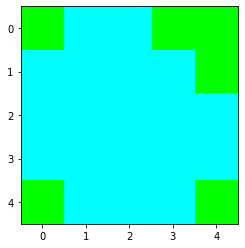

In [23]:
plt.imshow(img.astype('uint8'))

In [24]:
output[0].cpu()

tensor([[[ 1.4722,  1.5089,  1.4184,  ...,  2.5447,  1.8019,  1.8367],
         [ 1.5187,  1.5835,  1.6654,  ...,  2.8468,  2.4631,  2.1500],
         [ 1.2883,  1.6279,  1.5926,  ...,  2.7295,  2.2417,  2.1651],
         ...,
         [ 1.3886,  1.7078,  1.7805,  ...,  2.3288,  1.6692,  2.2489],
         [ 1.3712,  1.6200,  1.8177,  ...,  2.2978,  1.7420,  2.4505],
         [ 1.3749,  1.4495,  1.5496,  ...,  1.6298,  1.6204,  2.0496]],

        [[-1.2193, -1.2112, -1.1984,  ..., -1.9447, -1.8610, -1.3668],
         [-1.4553, -1.4660, -1.4084,  ..., -1.5250, -1.3379, -1.3386],
         [-1.4206, -1.5760, -1.5261,  ..., -1.9244, -1.6385, -1.5968],
         ...,
         [-1.4844, -1.6887, -1.6218,  ..., -1.9416, -1.6187, -1.5280],
         [-1.3923, -1.5810, -1.7610,  ..., -1.9183, -1.5497, -1.5643],
         [-1.0922, -1.1978, -1.1856,  ..., -1.0204, -0.9791, -1.1904]],

        [[ 0.9348,  0.3796,  0.2423,  ..., -0.1455,  0.5416,  0.7853],
         [ 0.7564,  0.3127, -0.0748,  ...,  0

In [25]:
img = preds[3].cpu().numpy()
y = y[3].cpu().numpy()
print(img.shape)

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

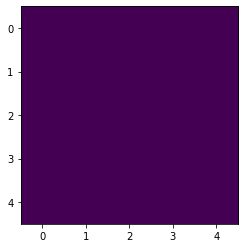

In [26]:
fig, ax = plt.subplots()
plt.imshow( img)

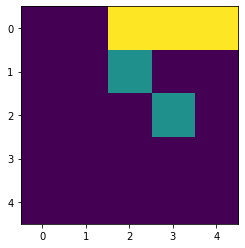

In [27]:
plt.imshow(y)

In [59]:
preds=preds.cpu().numpy()

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1


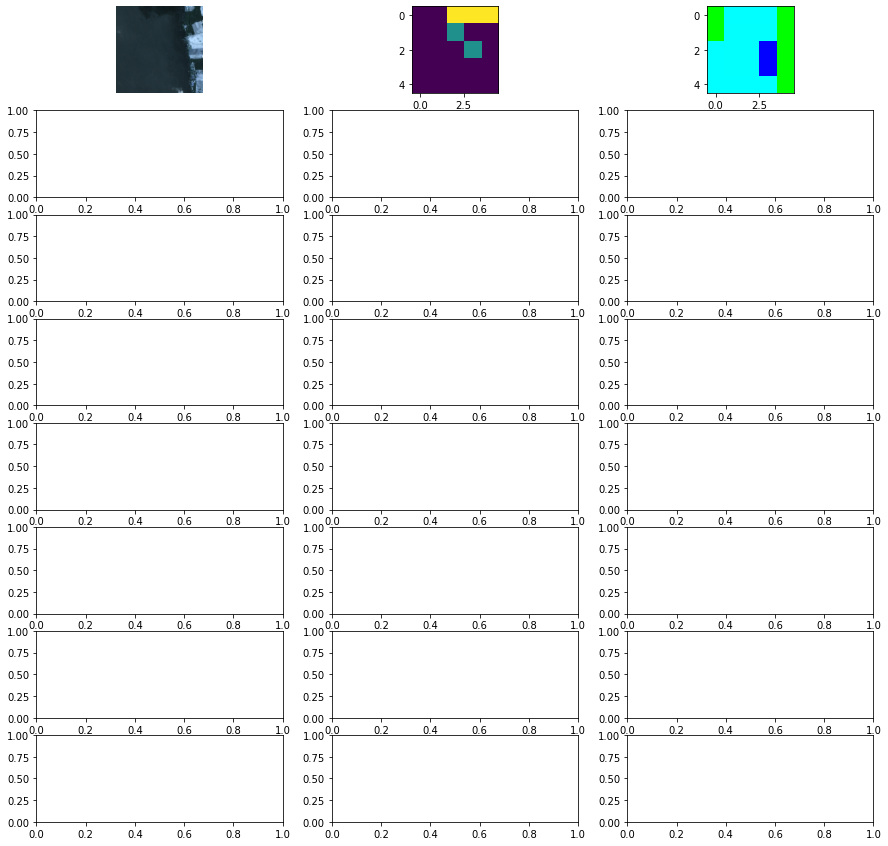

In [82]:
rows, cols = 8,3
num_images = len(batch['planet'])
fig, ax = plt.subplots(8,3, figsize = (15,15))

# x = x[0].cpu().numpy()
# x = np.moveaxis(x,0,2)
# y=  y[0].cpu().numpy()
# y = np.moveaxis(y,0,2)
# z = reduced_output[0].cpu().numpy()
# z = np.moveaxis(z, 0,2)
for i in range(num_images):
    row = i // cols  # Determine the row index
    col = i % cols   # Determine the column index
    print(row, col)
ax[0,0].imshow(x.astype('uint8'))
ax[0,0].axis('off')
ax[0,1].imshow(y)
ax[0,2].imshow(z.astype('uint8'))
plt.show()